# Data Polutan di Kabupaten Bangkalan
# Business Understanding
## 1.  Tujuan Mengetahui Kualitas Udara di Daerah Masing-Masing

  - Pemantauan Kondisi Lingkungan: Mendapatkan gambaran akurat terkait tingkat polusi udara.
  - Identifikasi Tren dan Pola: Mengetahui waktu dan lokasi terjadinya lonjakan polusi.
  - Peringatan Dini (Early Warning System): Memberikan peringatan kepada masyarakat saat kualitas udara berbahaya.
  - Evaluasi Kebijakan: Mengukur efektivitas kebijakan lingkungan yang sudah berjalan.

## 2.  Manfaat

  - Bagi Masyarakat: Perlindungan kesehatan dari risiko penyakit pernapasan dan peningkatan kualitas hidup.
  - Bagi Pemerintah: Menjadi dasar pembuatan regulasi (Data-Driven Policy) dan membantu pencapaian Sustainable Development Goals (SDGs).
  - Bagi Bisnis & Industri: Membantu kepatuhan standar lingkungan (ESG) dan membuka peluang inovasi (seperti air purifier dll).
  - Bagi Akademisi & Peneliti: Menyediakan dataset yang valid untuk keperluan riset lanjutan terkait iklim dan kesehatan.

# Data Understanding
Tahap prapemrosesan ini memanfaatkan platform OpenEO untuk memproses data satelit Sentinel-5P Level-2 secara cloud-based, mengurangi beban komputasi lokal dengan melakukan agregasi spasial dan temporal langsung di server.

## Deskripsi Fitur
- **CO (Karbon Monoksida):** Gas beracun yang tidak berwarna dan tidak berbau. Dihasilkan dari pembakaran yang tidak sempurna, seperti dari asap kendaraan bermotor dan kegiatan industri.
- **NO2 (Nitrogen Dioksida):** Gas berwarna coklat kemerahan dengan bau yang menyengat. Utamanya bersumber dari emisi kendaraan, pembangkit listrik, dan pembakaran bahan bakar fosil. Terpapar NO2 tingkat tinggi dapat merusak saluran pernapasan.
- **SO2 (Sulfur Dioksida):** Gas tidak berwarna berbau tajam (seperti belerang terbakar). Mayoritas berasal dari pembakaran batu bara atau minyak bumi yang mengandung belerang. SO2 berperan dalam pembentukan hujan asam.
- **O3 (Ozon):** Polutan sekunder yang terbentuk melalui reaksi fotokimia di atmosfer. Paparan O3 pada konsentrasi tinggi dapat mengiritasi saluran pernapasan dan dipengaruhi oleh intensitas cahaya matahari serta prekursor seperti NO2.

Pengecekan anomali (data aneh) dan *missing values* akan dieksplorasi lebih lanjut menggunakan *library* Pandas pada langkah akhir.

## 1. Persiapan Lingkungan dan Autentikasi
Langkah pertama adalah menginstal pustaka yang dibutuhkan dan melakukan autentikasi ke server Copernicus Data Space Ecosystem (CDSE) menggunakan OpenID Connect (OIDC).

In [1]:
!pip install openeo


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import openeo

In [3]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


### Penjelasan kode autentikasi

Kode sebelumnya mengimpor pustaka `openeo`, kemudian membuat koneksi ke layanan OpenEO Copernicus Data Space. Fungsi `authenticate_oidc()` melakukan autentikasi menggunakan OpenID Connect sehingga notebook dapat mengakses koleksi data Sentinel-5P dan mengirim proses analisis ke server.

## 2. Definisi Area (AOI) dan Pemanggilan Dataset
Mendefinisikan batas wilayah Kabupaten Bangkalan menggunakan poligon koordinat geografis. Selanjutnya, memanggil koleksi data gas polutan NO2, CO, SO2, dan O3 dari satelit Sentinel-5P untuk rentang waktu yang ditentukan.

![peta.png](./img/tugas1/peta.png)

In [4]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [
              113.0246284,
              -7.2136689
            ],
            [
              113.0863945,
              -6.8899587
            ],
            [
              112.8615302,
              -6.8911747
            ],
            [
              112.6774098,
              -7.0530501
            ],
            [
              112.7008918,
              -7.160955
            ],
            [
              113.0246284,
              -7.2136689
            ]
          ]
    ]
}

s5NO2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-25", "2026-08-25"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["NO2"],
)

s5CO = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-25", "2026-08-25"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["CO"],
)

s5SO2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-25", "2026-08-25"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["SO2"],
)

s5O3 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-25", "2026-08-25"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["O3"],
)

### Penjelasan kode pemanggilan data

Variabel `aoi` menyimpan batas wilayah Kabupaten Bangkalan dalam format GeoJSON Polygon. Fungsi `load_collection()` mengambil koleksi `SENTINEL_5P_L2` berdasarkan rentang waktu, batas koordinat, dan nama band polutan. Empat objek data dibuat untuk NO2, CO, SO2, dan O3 agar setiap polutan dapat diproses secara terpisah.

## 3. Agregasi Spasio-Temporal dan Eksekusi Server
Data satelit resolusi tinggi direduksi (diagregasi) menjadi nilai rata-rata harian (temporal) dan nilai rata-rata per wilayah AOI (spasial). Proses ini kemudian dikirim sebagai batch job untuk dieksekusi di server dan diunduh sebagai file NetCDF (.nc).

In [5]:
# agregasi berdasarkan hari untuk menghindari adanya beberapa data per hari
s5p_NO2_daily = s5NO2.aggregate_temporal_period(reducer="mean", period="day")
s5p_CO_daily = s5CO.aggregate_temporal_period(reducer="mean", period="day")
s5p_SO2_daily = s5SO2.aggregate_temporal_period(reducer="mean", period="day")
s5p_O3_daily = s5O3.aggregate_temporal_period(reducer="mean", period="day")

# agregasi untuk menghasilkan data deret waktu rata-rata
s5p_NO2_aoi = s5p_NO2_daily.aggregate_spatial(reducer="mean", geometries=aoi)
s5p_CO_aoi = s5p_CO_daily.aggregate_spatial(reducer="mean", geometries=aoi)
s5p_SO2_aoi = s5p_SO2_daily.aggregate_spatial(reducer="mean", geometries=aoi)
s5p_O3_aoi = s5p_O3_daily.aggregate_spatial(reducer="mean", geometries=aoi)

### Penjelasan kode agregasi

`aggregate_temporal_period(reducer="mean", period="day")` menghitung rata-rata data pada setiap hari. Setelah itu, `aggregate_spatial(reducer="mean", geometries=aoi)` menghitung rata-rata nilai di dalam wilayah AOI. Hasilnya adalah deret waktu harian yang mewakili kondisi rata-rata Kabupaten Bangkalan untuk setiap polutan.

In [6]:
# Eksekusi batch job dan unduh hasil ke format NetCDF (.nc)
job = s5p_NO2_aoi.execute_batch(title="NO2 in Bangkalan terbaru", outputfile="NO2Bangkalan Terbaru.nc")

0:00:00 Job 'j-260920143219466c9fe637bd936bbe4e': send 'start'


0:00:03 Job 'j-260920143219466c9fe637bd936bbe4e': queued (progress 0%)


0:00:09 Job 'j-260920143219466c9fe637bd936bbe4e': queued (progress 0%)


0:00:15 Job 'j-260920143219466c9fe637bd936bbe4e': queued (progress 0%)


0:00:24 Job 'j-260920143219466c9fe637bd936bbe4e': queued (progress 0%)


In [7]:
job = s5p_CO_aoi.execute_batch(title="CO in Bangkalan terbaru", outputfile="COBangkalan Terbaru.nc")

0:00:00 Job 'j-2609041259344ff0824bce18764dee9e': send 'start'
0:00:06 Job 'j-2609041259344ff0824bce18764dee9e': queued (progress 0%)
0:00:12 Job 'j-2609041259344ff0824bce18764dee9e': queued (progress 0%)
0:00:19 Job 'j-2609041259344ff0824bce18764dee9e': queued (progress 0%)
0:00:27 Job 'j-2609041259344ff0824bce18764dee9e': queued (progress 0%)
0:00:41 Job 'j-2609041259344ff0824bce18764dee9e': queued (progress 0%)
0:00:55 Job 'j-2609041259344ff0824bce18764dee9e': queued (progress 0%)
0:01:11 Job 'j-2609041259344ff0824bce18764dee9e': queued (progress 0%)
0:01:31 Job 'j-2609041259344ff0824bce18764dee9e': queued (progress 0%)
0:01:55 Job 'j-2609041259344ff0824bce18764dee9e': running (progress N/A)
0:02:25 Job 'j-2609041259344ff0824bce18764dee9e': running (progress N/A)
0:03:03 Job 'j-2609041259344ff0824bce18764dee9e': running (progress N/A)
0:03:50 Job 'j-2609041259344ff0824bce18764dee9e': running (progress N/A)
0:04:48 Job 'j-2609041259344ff0824bce18764dee9e': running (progress N/A)
0:05

In [13]:
job = s5p_SO2_aoi.execute_batch(title="SO2 in Bangkalan terbaru", outputfile="SO2Bangkalan Terbaru.nc")

job = s5p_O3_aoi.execute_batch(title="O3 in Bangkalan terbaru", outputfile="O3Bangkalan Terbaru.nc")

0:00:00 Job 'j-260904132439439ca6825b31e31dab3d': send 'start'
0:00:07 Job 'j-260904132439439ca6825b31e31dab3d': queued (progress 0%)
0:00:12 Job 'j-260904132439439ca6825b31e31dab3d': queued (progress 0%)
0:00:19 Job 'j-260904132439439ca6825b31e31dab3d': queued (progress 0%)
0:00:27 Job 'j-260904132439439ca6825b31e31dab3d': queued (progress 0%)
0:00:37 Job 'j-260904132439439ca6825b31e31dab3d': queued (progress 0%)
0:00:50 Job 'j-260904132439439ca6825b31e31dab3d': queued (progress 0%)
0:01:05 Job 'j-260904132439439ca6825b31e31dab3d': queued (progress 0%)
0:01:25 Job 'j-260904132439439ca6825b31e31dab3d': running (progress N/A)
0:01:49 Job 'j-260904132439439ca6825b31e31dab3d': running (progress N/A)
0:02:19 Job 'j-260904132439439ca6825b31e31dab3d': running (progress N/A)
0:02:57 Job 'j-260904132439439ca6825b31e31dab3d': running (progress N/A)
0:03:44 Job 'j-260904132439439ca6825b31e31dab3d': running (progress N/A)
0:04:43 Job 'j-260904132439439ca6825b31e31dab3d': running (progress N/A)
0:

### Penjelasan kode batch job

`execute_batch()` mengirim proses pengolahan data ke server OpenEO. Parameter `title` memberi nama pekerjaan, sedangkan `outputfile` menentukan nama file NetCDF yang diunduh setelah proses selesai. Tahap ini dilakukan untuk masing-masing polutan, termasuk O3.

## 4. Transformasi Data (NetCDF ke CSV)
Membaca file multi-dimensi NetCDF hasil unduhan, mengekstrak nilai polutan beserta atribut waktunya, melakukan penyesuaian format tanggal (YYYY-MM-DD), dan merestrukturisasinya menjadi format DataFrame menggunakan Pandas untuk disimpan sebagai CSV.

In [9]:
!pip install netCDF4


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HYPE AMD\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [14]:
import netCDF4
import numpy as np
import pandas as pd

def safe_date_list(time_values, units=None):
    try:
        if units:
            dates = netCDF4.num2date(time_values, units=units)
        else:
            dates = time_values
    except Exception:
        dates = time_values

    out = []
    for value in dates:
        if hasattr(value, "strftime"):
            out.append(value.strftime("%Y-%m-%d"))
        elif isinstance(value, np.datetime64):
            out.append(pd.to_datetime(str(value)).strftime("%Y-%m-%d"))
        else:
            try:
                out.append(pd.to_datetime(value).strftime("%Y-%m-%d"))
            except Exception:
                out.append(str(value))
    return out

dsNO2 = netCDF4.Dataset("NO2Bangkalan Terbaru.nc")
dsCO = netCDF4.Dataset("COBangkalan Terbaru.nc")
dsSO2 = netCDF4.Dataset("SO2Bangkalan Terbaru.nc")
dsO3 = netCDF4.Dataset("O3Bangkalan Terbaru.nc")

In [11]:
values = np.asarray(dsNO2.variables["NO2"][:])
if values.ndim > 1:
    values = values.squeeze()

timeNO2 = dsNO2.variables["t"][:]
unitsNO2 = getattr(dsNO2.variables["t"], "units", None)
dates = safe_date_list(timeNO2, unitsNO2)

if len(dates) != len(values):
    n = min(len(dates), len(values))
    dates = dates[:n]
    values = values[:n]

df = pd.DataFrame({
    "date": dates,
    "NO2": values
})

df.to_csv("NO2_Bangkalan_timeseries_terbaru.csv", index=False)

In [12]:
values = np.asarray(dsCO.variables["CO"][:])
if values.ndim > 2:
    values = values.mean(axis=(1, 2))
elif values.ndim == 2:
    values = values.squeeze()
    if values.ndim > 1:
        values = values.mean(axis=0)
else:
    values = values.reshape(-1)

timeCO = dsCO.variables["t"][:]
unitsCO = getattr(dsCO.variables["t"], "units", None)
dates = safe_date_list(timeCO, unitsCO)

if len(dates) != len(values):
    n = min(len(dates), len(values))
    dates = dates[:n]
    values = values[:n]

df = pd.DataFrame({
    "date": dates,
    "CO": values
})

df.to_csv("CO_Bangkalan_timeseries_terbaru.csv", index=False)

In [13]:
values = np.asarray(dsSO2.variables["SO2"][:])
if values.ndim > 2:
    values = values.mean(axis=(1, 2))
elif values.ndim == 2:
    values = values.squeeze()
    if values.ndim > 1:
        values = values.mean(axis=0)
else:
    values = values.reshape(-1)

timeSO2 = dsSO2.variables["t"][:]
unitsSO2 = getattr(dsSO2.variables["t"], "units", None)
dates = safe_date_list(timeSO2, unitsSO2)

if len(dates) != len(values):
    n = min(len(dates), len(values))
    dates = dates[:n]
    values = values[:n]

# Buat dataframe dan simpan ke CSV
if len(dates) != len(values):
    n = min(len(dates), len(values))
    dates = dates[:n]
    values = values[:n]

df = pd.DataFrame({
    "date": dates,
    "SO2": values
})

df.to_csv("SO2_Bangkalan_timeseries_terbaru.csv", index=False)

In [16]:
values = np.asarray(dsO3.variables["O3"][:])
if values.ndim > 2:
    values = values.mean(axis=tuple(range(1, values.ndim)))
elif values.ndim == 2:
    values = values.squeeze()
    if values.ndim > 1:
        values = values.mean(axis=0)
else:
    values = values.reshape(-1)

timeO3 = dsO3.variables["t"][:]
unitsO3 = getattr(dsO3.variables["t"], "units", None)
dates = safe_date_list(timeO3, unitsO3)

if len(dates) != len(values):
    n = min(len(dates), len(values))
    dates = dates[:n]
    values = values[:n]

df = pd.DataFrame({
    "date": dates,
    "O3": values
})

df.to_csv("O3_Bangkalan_timeseries_terbaru.csv", index=False)

### Penjelasan kode transformasi O3

Kode transformasi membaca nilai O3 dan waktu dari file NetCDF. Jika data memiliki lebih dari satu dimensi, nilai spasial dirata-ratakan agar tersisa satu nilai per waktu. Fungsi `safe_date_list()` mengubah koordinat waktu NetCDF menjadi format tanggal `YYYY-MM-DD`. Data tanggal dan nilai O3 kemudian disimpan sebagai CSV agar mudah dianalisis dengan Pandas.

## 5. Eksplorasi Data (Pencarian Data Aneh / Outlier)
Langkah ini bertujuan untuk memastikan kelengkapan data hasil ekstraksi. Keempat file CSV polutan akan dimuat ke dalam satu *dataframe* terpadu untuk mengecek *missing values* dan mendeskripsikan statistik setiap polutan.

In [14]:
import pandas as pd

# Memuat ulang data dari file CSV yang sudah dibuat
df_no2 = pd.read_csv("NO2_Bangkalan_timeseries_terbaru.csv")
df_co = pd.read_csv("CO_Bangkalan_timeseries_terbaru.csv")
df_so2 = pd.read_csv("SO2_Bangkalan_timeseries_terbaru.csv")

# Menggabungkan data berdasarkan kolom 'date'
df_combined = df_no2.merge(df_co, on='date', how='outer').merge(df_so2, on='date', how='outer')

for col in ['NO2', 'CO', 'SO2']:
    df_combined[col] = pd.to_numeric(df_combined[col], errors='coerce')

# Konversi kolom 'date' ke tipe datetime Pandas untuk konsistensi
df_combined['date'] = pd.to_datetime(df_combined['date'])

print("========== Pengecekan Missing Values ==========")
print(df_combined.isnull().sum())
print("\n========== Pengecekan Data Aneh (Deskripsi Statistik) ==========")
print(df_combined.describe())

========== Pengecekan Missing Values ==========
date     0
NO2     33
CO      40
SO2     16
dtype: int64

========== Pengecekan Data Aneh (Deskripsi Statistik) ==========
                                date           NO2          CO         SO2
count                            310  2.770000e+02  270.000000  294.000000
mean   2026-03-04 13:05:01.935483904  2.415902e-05    0.028614    0.000032
min              2025-08-25 00:00:00 -6.819737e-07    0.020487   -0.000821
25%              2025-12-02 06:00:00  1.740374e-05    0.026734   -0.000026
50%              2026-03-15 12:00:00  2.284575e-05    0.028324    0.000031
75%              2026-06-06 18:00:00  3.019271e-05    0.030207    0.000089
max              2026-08-24 00:00:00  7.737131e-05    0.044761    0.000592
std                              NaN  1.004711e-05    0.002931    0.000131


### Penjelasan kode eksplorasi data

Keempat file CSV dibaca menggunakan Pandas lalu digabung berdasarkan kolom `date`. Nilai polutan dikonversi menjadi numerik dengan `errors="coerce"` sehingga teks yang tidak valid berubah menjadi nilai kosong. `isnull().sum()` menghitung data yang hilang, sedangkan `describe()` menampilkan jumlah data, rata-rata, standar deviasi, nilai minimum, kuartil, dan maksimum.

# 6. Missing values

### Penjelasan bagian Missing Values

Missing value adalah data yang tidak memiliki nilai pengamatan atau bernilai kosong. Pemeriksaan pada bagian ini dilakukan dengan dua cara:

1. **Pengecekan tanggal yang hilang:** `pd.date_range()` membuat daftar tanggal harian lengkap dari 1 Januari 2025 sampai 26 Agustus 2026. Method `difference()` membandingkan daftar tersebut dengan kolom `date` untuk menemukan tanggal yang tidak tersedia pada masing-masing polutan.
2. **Pengecekan nilai kosong:** `isna().sum()` menghitung jumlah nilai kosong pada kolom konsentrasi setiap polutan. Nilai kosong dapat terjadi karena tidak ada observasi satelit yang valid pada tanggal atau wilayah tertentu.

Hasil pemeriksaan tanggal dan nilai kosong perlu dibedakan. Suatu file dapat memiliki `0` nilai kosong pada tanggal yang tersedia, tetapi tetap memiliki tanggal yang hilang karena pengamatan satelit tidak tersedia pada semua hari. Informasi ini penting agar analisis tren dan perbandingan antarpolutan tidak ditafsirkan secara berlebihan.

## NO2

In [16]:
import pandas as pd

df = pd.read_csv("NO2_Bangkalan_timeseries_terbaru.csv")
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2025-01-01"
end_date   = "2026-08-26"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 326
Daftar tanggal missing:
DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
               '2025-01-09', '2025-01-10',
               ...
               '2026-04-11', '2026-04-27', '2026-04-29', '2026-04-30',
               '2026-05-30', '2026-06-12', '2026-06-23', '2026-07-27',
               '2026-08-25', '2026-08-26'],
              dtype='datetime64[ns]', length=326, freq=None)


## CO

In [17]:
import pandas as pd

df = pd.read_csv("CO_Bangkalan_timeseries_terbaru.csv")
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2025-01-01"
end_date   = "2026-08-26"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 333
Daftar tanggal missing:
DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
               '2025-01-09', '2025-01-10',
               ...
               '2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30',
               '2026-05-04', '2026-06-12', '2026-07-11', '2026-07-27',
               '2026-08-25', '2026-08-26'],
              dtype='datetime64[ns]', length=333, freq=None)


## SO2

In [18]:
import pandas as pd

df = pd.read_csv("SO2_Bangkalan_timeseries_terbaru.csv")
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2025-01-01"
end_date   = "2026-08-26"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 309
Daftar tanggal missing:
DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
               '2025-01-09', '2025-01-10',
               ...
               '2026-03-28', '2026-04-04', '2026-04-10', '2026-04-27',
               '2026-04-29', '2026-05-05', '2026-06-12', '2026-07-06',
               '2026-08-25', '2026-08-26'],
              dtype='datetime64[ns]', length=309, freq=None)


## O3

In [17]:
import pandas as pd

df = pd.read_csv("O3_Bangkalan_timeseries_terbaru.csv")
df['date'] = pd.to_datetime(df['date'])

start_date = "2025-01-01"
end_date = "2026-08-26"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 242
Daftar tanggal missing:
DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
               '2025-01-09', '2025-01-10',
               ...
               '2025-08-21', '2025-08-22', '2025-08-23', '2025-08-24',
               '2025-09-20', '2025-09-30', '2026-05-05', '2026-07-06',
               '2026-08-25', '2026-08-26'],
              dtype='datetime64[ns]', length=242, freq=None)


# Data yang hilang

NO2

In [19]:
df = pd.read_csv("NO2_Bangkalan_timeseries_terbaru.csv")
missing_value = df['NO2'].isna().sum()
print(missing_value)

0


CO

In [22]:
df = pd.read_csv("CO_Bangkalan_timeseries_terbaru.csv")
missing_value = df['CO'].isna().sum()
print(missing_value)

0


O3

In [18]:
df = pd.read_csv("O3_Bangkalan_timeseries_terbaru.csv")
missing_value = df['O3'].isna().sum()
print(missing_value)

0


# 7. Outliers

NO2

In [1]:
import pandas as pd
from sklearn.ensemble import IsolationForest

df = pd.read_csv("NO2_Bangkalan_timeseries_terbaru.csv")
df_clean = df.dropna(subset=['NO2']).copy()

model = IsolationForest(contamination=0.05, random_state=42) # contamination 0.05 = 5%
pred = model.fit_predict(df_clean[['NO2']])

# Nilai -1 merepresentasikan outlier
jumlah_outlier = (pred == -1).sum()
print("Jumlah outlier:", jumlah_outlier)

Jumlah outlier: 14


CO

In [3]:
import pandas as pd
from sklearn.ensemble import IsolationForest

df = pd.read_csv("CO_Bangkalan_timeseries_terbaru.csv")
df_clean = df.dropna(subset=['CO']).copy()

model = IsolationForest(contamination=0.05, random_state=42) # contamination 0.05 = 5%
pred = model.fit_predict(df_clean[['CO']])

# Nilai -1 merepresentasikan outlier
jumlah_outlier = (pred == -1).sum()
print("Jumlah outlier:", jumlah_outlier)

Jumlah outlier: 14


SO2

In [4]:
import pandas as pd
from sklearn.ensemble import IsolationForest

df = pd.read_csv("SO2_Bangkalan_timeseries_terbaru.csv")
df_clean = df.dropna(subset=['SO2']).copy()

model = IsolationForest(contamination=0.05, random_state=42) # contamination 0.05 = 5%
pred = model.fit_predict(df_clean[['SO2']])

# Nilai -1 merepresentasikan outlier
jumlah_outlier = (pred == -1).sum()
print("Jumlah outlier:", jumlah_outlier)

Jumlah outlier: 15


O3

In [19]:
import pandas as pd
from sklearn.ensemble import IsolationForest

df = pd.read_csv("O3_Bangkalan_timeseries_terbaru.csv")
df_clean = df.dropna(subset=['O3']).copy()

model = IsolationForest(contamination=0.05, random_state=42)
pred = model.fit_predict(df_clean[['O3']])

jumlah_outlier = (pred == -1).sum()
print("Jumlah outlier:", jumlah_outlier)

Jumlah outlier: 17


### Penjelasan kode deteksi outlier

`dropna()` menghapus baris yang tidak memiliki nilai polutan. `IsolationForest` kemudian dilatih menggunakan satu kolom polutan untuk mengidentifikasi nilai yang berbeda jauh dari pola umum. Hasil `-1` dianggap sebagai outlier, sedangkan hasil `1` dianggap sebagai data normal. Parameter `contamination=0.05` memperkirakan sekitar 5% data sebagai outlier.

# 8. Hasil Data Polutan

In [20]:
import pandas as pd

df_co = pd.read_csv("CO_Bangkalan_timeseries_terbaru.csv")
df_no2 = pd.read_csv("NO2_Bangkalan_timeseries_terbaru.csv")
df_so2 = pd.read_csv("SO2_Bangkalan_timeseries_terbaru.csv")
df_o3 = pd.read_csv("O3_Bangkalan_timeseries_terbaru.csv")

dataframe_merged = df_no2[['date', 'NO2']].merge(
    df_co[['date', 'CO']], on='date', how='outer'
).merge(
    df_so2[['date', 'SO2']], on='date', how='outer'
).merge(
    df_o3[['date', 'O3']], on='date', how='outer'
)

dataframe_merged['date'] = pd.to_datetime(dataframe_merged['date'])
dataframe_merged = dataframe_merged.sort_values('date')
dataframe_merged.to_csv("Polutan_Bangkalan.csv", index=False)

### Penjelasan kode penggabungan data

Setiap CSV dipilih pada kolom tanggal dan polutannya, kemudian digabung menggunakan `outer merge`. Cara ini mempertahankan semua tanggal dari seluruh polutan, meskipun suatu polutan tidak memiliki pengamatan pada tanggal tertentu. Data gabungan diurutkan berdasarkan tanggal dan disimpan sebagai `Polutan_Bangkalan.csv`.

## 9. Visualisasi Grafik Time Series
Sesuai kebutuhan tugas, data polutan NO2, CO, SO2, dan O3 dari periode pengamatan sekitar Agustus 2025 hingga Agustus 2026 divisualisasikan dalam bentuk grafik deret waktu (*time series*). Grafik ini membantu melihat tren, fluktuasi, dan periode puncak konsentrasi setiap polutan.

In [15]:
!pip install matplotlib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HYPE AMD\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


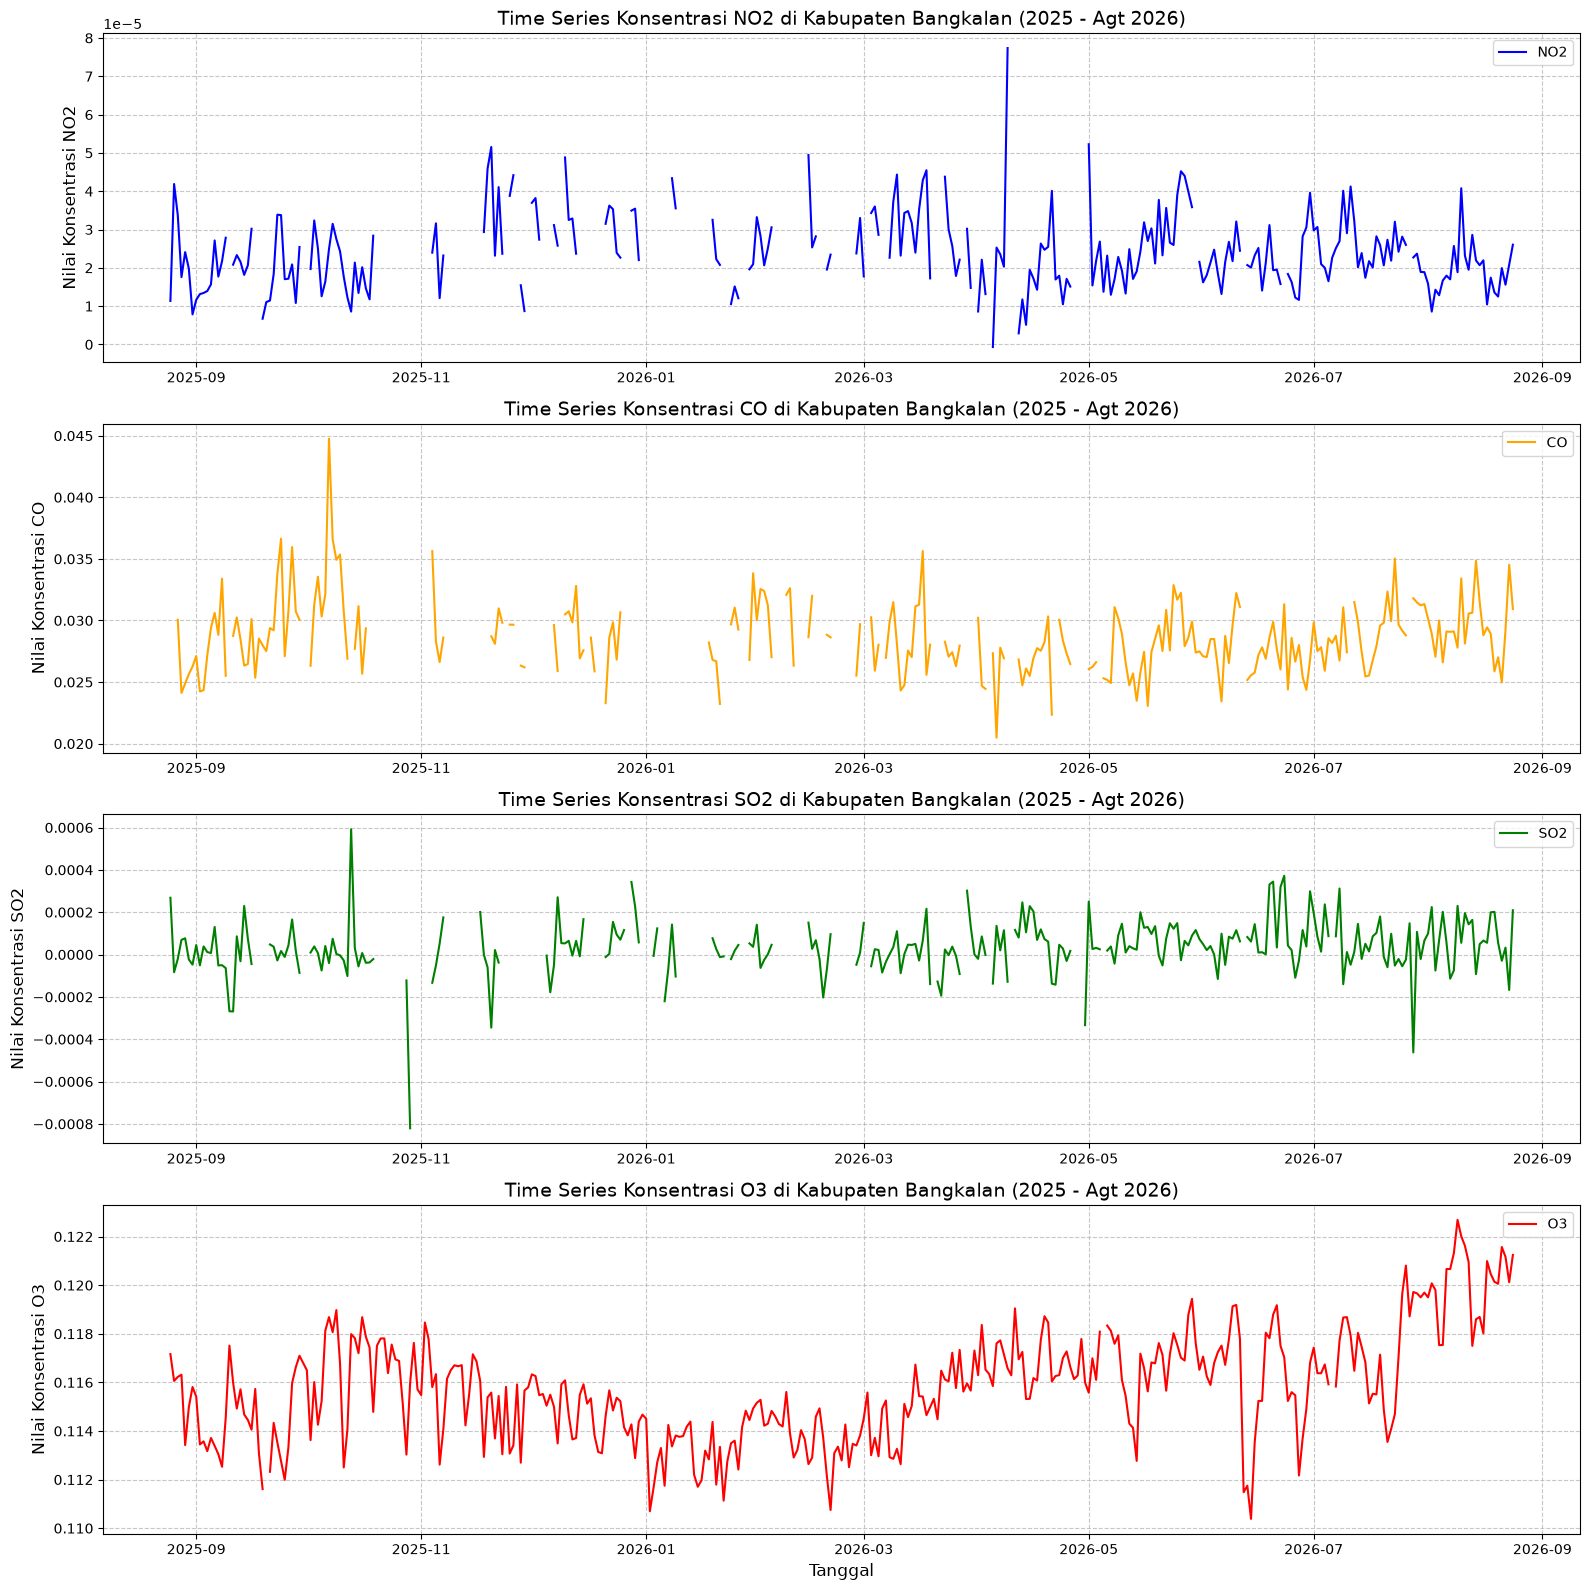

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df_combined = pd.read_csv("Polutan_Bangkalan.csv")
df_combined['date'] = pd.to_datetime(df_combined['date'])
df_combined = df_combined.sort_values(by='date')

plt.figure(figsize=(16, 16))

pollutants = [
    ('NO2', 'blue'),
    ('CO', 'orange'),
    ('SO2', 'green'),
    ('O3', 'red'),
]

for index, (pollutant, color) in enumerate(pollutants, start=1):
    plt.subplot(4, 1, index)
    plt.plot(
        df_combined['date'],
        df_combined[pollutant],
        color=color,
        label=pollutant,
        linewidth=1.5,
    )
    plt.title(
        f'Time Series Konsentrasi {pollutant} di Kabupaten Bangkalan (2025 - Agt 2026)',
        fontsize=14,
    )
    plt.ylabel(f'Nilai Konsentrasi {pollutant}', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

plt.xlabel('Tanggal', fontsize=12)
plt.tight_layout()
plt.show()

### Penjelasan kode visualisasi

File CSV gabungan dibaca kembali lalu kolom `date` dikonversi menjadi tipe datetime dan diurutkan. Daftar `pollutants` menentukan nama serta warna grafik. Perulangan `for` membuat satu subplot untuk setiap polutan, sehingga NO2, CO, SO2, dan O3 dapat dibandingkan berdasarkan perubahan konsentrasinya terhadap waktu.

## Interpretasi Grafik Time Series

Grafik time series menunjukkan perubahan konsentrasi NO2, CO, SO2, dan O3 di Kabupaten Bangkalan selama periode pengamatan sekitar Agustus 2025 hingga Agustus 2026. Jumlah observasi berbeda antar polutan karena tidak setiap hari menghasilkan data satelit yang valid pada area kajian.

- **NO2** memiliki rata-rata sekitar **2,42 × 10^-5** dengan nilai maksimum **7,74 × 10^-5** pada **9 April 2026**. Polanya berfluktuasi cukup kuat dan terdapat beberapa nilai yang mendekati atau berada di bawah nol, sehingga nilai ekstrem perlu dipahami sebagai hasil retrieval satelit dan bukan langsung sebagai konsentrasi negatif di atmosfer.
- **CO** menunjukkan pola yang relatif lebih stabil dibandingkan NO2 dan SO2. Nilai rata-ratanya sekitar **0,02861**, sedangkan nilai maksimum **0,04476** terjadi pada **7 Oktober 2025**. Lonjakan ini dapat berkaitan dengan perubahan aktivitas pembakaran, transportasi, atau kondisi atmosfer.
- **SO2** memiliki rata-rata sekitar **3,25 × 10^-5**, dengan maksimum **5,92 × 10^-4** pada **13 Oktober 2025**. Grafik memperlihatkan fluktuasi paling ekstrem, termasuk nilai minimum sekitar **-8,21 × 10^-4**. Nilai negatif dan lonjakan tersebut perlu ditafsirkan hati-hati karena dapat dipengaruhi noise atau proses retrieval data satelit.
- **O3** memiliki rata-rata sekitar **0,11577** dan menunjukkan kecenderungan meningkat pada bagian akhir periode pengamatan. Nilai maksimum **0,12269** terjadi pada **9 Agustus 2026**, sementara nilai minimum sekitar **0,11038**. O3 memperlihatkan pola temporal yang berbeda dari polutan lainnya, terutama dengan peningkatan konsentrasi pada pertengahan hingga akhir 2026.

Secara keseluruhan, grafik memperlihatkan bahwa kualitas udara di Kabupaten Bangkalan berubah-ubah sepanjang waktu. NO2, CO, SO2, dan O3 memiliki pola temporal yang berbeda, dengan beberapa lonjakan pada NO2, CO, dan SO2 serta kecenderungan peningkatan O3 menjelang akhir periode. Hasil ini berguna untuk menemukan periode yang perlu dikaji lebih lanjut, tetapi belum cukup untuk menyatakan tingkat risiko kesehatan tanpa pembandingan terhadap baku mutu dan validasi dengan pengukuran stasiun permukaan.

# Kesimpulan

Berdasarkan analisis data kualitas udara Kabupaten Bangkalan dari produk Sentinel-5P untuk periode sekitar Agustus 2025 hingga Agustus 2026, dapat disimpulkan bahwa:

- Data **NO2, CO, SO2, dan O3** berhasil diproses dari format NetCDF menjadi deret waktu CSV, kemudian digabungkan dan divisualisasikan dalam satu grafik.
- Seluruh kolom polutan tidak memiliki missing value pada CSV hasil ekstraksi. Namun, jumlah tanggal pengamatan berbeda antar polutan karena ketersediaan data satelit yang valid tidak sama setiap hari.
- **NO2** memiliki rata-rata sekitar **2,42 × 10^-5** dan mencapai maksimum **7,74 × 10^-5** pada **9 April 2026**.
- **CO** memiliki rata-rata sekitar **0,02861** dan maksimum **0,04476** pada **7 Oktober 2025**, dengan pola yang relatif lebih stabil dibandingkan NO2 dan SO2.
- **SO2** memiliki rata-rata sekitar **3,25 × 10^-5** dan maksimum **5,92 × 10^-4** pada **13 Oktober 2025**. Nilai ekstrem, termasuk nilai negatif, menunjukkan bahwa data perlu melalui pemeriksaan kualitas dan interpretasi lebih lanjut.
- **O3** memiliki rata-rata sekitar **0,11577** dan maksimum **0,12269** pada **9 Agustus 2026**. Grafik menunjukkan kecenderungan peningkatan O3 pada bagian akhir periode pengamatan.
- Setiap polutan memiliki pola temporal berbeda. NO2, CO, dan SO2 menunjukkan beberapa lonjakan selama periode pengamatan, sedangkan O3 cenderung meningkat mendekati akhir periode.

Dengan demikian, data Sentinel-5P dapat digunakan untuk memantau variasi spasial-temporal polutan udara di Kabupaten Bangkalan dan membantu menemukan periode yang perlu diperhatikan. Namun, hasil ini sebaiknya tidak langsung dianggap sebagai penilaian risiko kesehatan karena perlu dibandingkan dengan baku mutu yang sesuai, dikaji berdasarkan satuan masing-masing produk, serta divalidasi menggunakan data pengukuran permukaan. Nilai negatif dan tanggal yang hilang juga perlu dipertimbangkan dalam analisis lanjutan.